# GLOBAL CRUDE OIL PRODUCTION ANALYSIS 

## A DATA ANALYSIS PROJECT USING PYTHON
**AUTHOR:** ANUSHKA KUMARI

**Tools used:** Python, Pandas, Matplotlib

**Dataset:** crude oil Production Dataset

# Project Objective

The objective of this project is to analyze global crude oil production data to identify production trends, compare oil-producing countries, and discover meaningful insights using data analysis and visualization techniques.

This project demonstrates the complete data analysis workflow, including data loading, data cleaning, exploratory data analysis (EDA), visualization, and interpretation of results.

In [1]:
# Import required libraries

import pandas as pd
import matplotlib.pyplot as plt

# Loading the Dataset

In [2]:
crude_oil_data = pd.read_csv("../data/crude_oil_production.csv")

In [3]:
crude_oil_data.head()

,LOCATION,INDICATOR,SUBJECT,MEASURE,FREQUENCY,TIME,Value,Flag Codes
0,AUS,OILPROD,TOT,KTOE,A,1960,NaN,L
1,AUS,OILPROD,TOT,KTOE,A,1961,NaN,L
2,AUS,OILPROD,TOT,KTOE,A,1962,NaN,L
3,AUS,OILPROD,TOT,KTOE,A,1963,NaN,L
4,AUS,OILPROD,TOT,KTOE,A,1964,NaN,L


## Dataset Dimensions

The first step is to determine the size of the dataset by identifying the total number of rows and columns. This helps us understand the volume of data available for analysis.

In [4]:
# Display the number of rows and columns
crude_oil_data.shape

(8236, 8)

## Column Names

Understanding the column names helps identify the variables available in the dataset and provides a clear idea of the information collected.

In [5]:
# Display all column names
crude_oil_data.columns

Index(['LOCATION', 'INDICATOR', 'SUBJECT', 'MEASURE', 'FREQUENCY', 'TIME',
       'Value', 'Flag Codes'],
      dtype='object')

## Data Types and Missing Values

Examining the data types and identifying missing values ensures that each column is stored in an appropriate format for analysis.

In [6]:
# Display dataset information
crude_oil_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8236 entries, 0 to 8235
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   LOCATION    8236 non-null   object 
 1   INDICATOR   8236 non-null   object 
 2   SUBJECT     8236 non-null   object 
 3   MEASURE     8236 non-null   object 
 4   FREQUENCY   8236 non-null   object 
 5   TIME        8236 non-null   int64  
 6   Value       6104 non-null   float64
 7   Flag Codes  2132 non-null   object 
dtypes: float64(1), int64(1), object(6)
memory usage: 514.9+ KB


## Summary Statistics

Summary statistics provide an overview of the numerical variables, including measures such as count, mean, standard deviation, minimum, and maximum values.

In [7]:
# Generate summary statistics
crude_oil_data.describe()

,TIME,Value
count,8236.000000,6.104000e+03
mean,1988.500000,6.533908e+04
std,16.741685,3.259844e+05
min,1960.000000,0.000000e+00
25%,1974.000000,0.000000e+00
50%,1988.500000,6.620815e+02
75%,2003.000000,1.425258e+04
max,2017.000000,3.991795e+06


# Data Cleaning and Preprocessing

Before performing data analysis, it is essential to clean the dataset to ensure accuracy and consistency. In this section, we will identify missing values, duplicate records, unnecessary columns, and any inconsistencies that may affect the analysis.

In [8]:
# Check missing values in each column

crude_oil_data.isnull().sum()

LOCATION         0
INDICATOR        0
SUBJECT          0
MEASURE          0
FREQUENCY        0
TIME             0
Value         2132
Flag Codes    6104
dtype: int64

In [9]:
# Check for duplicate rows

crude_oil_data.duplicated().sum()

0

In [10]:
crude_oil_data["INDICATOR"].unique()

array(['OILPROD'], dtype=object)

In [11]:
crude_oil_data["SUBJECT"].unique()

array(['TOT'], dtype=object)

In [12]:
crude_oil_data["MEASURE"].unique()

array(['KTOE'], dtype=object)

In [13]:
crude_oil_data["FREQUENCY"].unique()

array(['A'], dtype=object)

In [14]:
crude_oil_data["Flag Codes"].unique()

array(['L', nan], dtype=object)

In [15]:
crude_oil_data["Flag Codes"].value_counts(dropna=False)

Flag Codes
NaN    6104
L      2132
Name: count, dtype: int64

In [16]:
crude_oil_data[crude_oil_data["Flag Codes"] == "L"]

,LOCATION,INDICATOR,SUBJECT,MEASURE,FREQUENCY,TIME,Value,Flag Codes
0,AUS,OILPROD,TOT,KTOE,A,1960,NaN,L
1,AUS,OILPROD,TOT,KTOE,A,1961,NaN,L
2,AUS,OILPROD,TOT,KTOE,A,1962,NaN,L
3,AUS,OILPROD,TOT,KTOE,A,1963,NaN,L
4,AUS,OILPROD,TOT,KTOE,A,1964,NaN,L
...,...,...,...,...,...,...,...,...
8184,ZWE,OILPROD,TOT,KTOE,A,1966,NaN,L
8185,ZWE,OILPROD,TOT,KTOE,A,1967,NaN,L
8186,ZWE,OILPROD,TOT,KTOE,A,1968,NaN,L
8187,ZWE,OILPROD,TOT,KTOE,A,1969,NaN,L


## Removing Unnecessary Columns

### Objective

Some columns contain only a single unique value across the entire dataset and therefore do not contribute meaningful information to the analysis. Additionally, the **Flag Codes** column only indicates missing production values, which can already be identified directly from the **Value** column.

To simplify the dataset and improve readability, these columns will be removed.

In [17]:
# Remove columns that do not provide additional analytical value

crude_oil_data = crude_oil_data.drop(
    columns=["INDICATOR", "SUBJECT", "MEASURE", "FREQUENCY", "Flag Codes"]
)

# Display the first five rows after removing unnecessary columns
crude_oil_data.head()

,LOCATION,TIME,Value
0,AUS,1960,NaN
1,AUS,1961,NaN
2,AUS,1962,NaN
3,AUS,1963,NaN
4,AUS,1964,NaN


## Handling Missing Values

### Objective

The **Value** column contains missing production values. Since these values represent the primary variable used in the analysis, they cannot be accurately estimated without introducing bias.

Instead of replacing the missing values with zeros or averages, the rows containing missing production values will be removed to ensure that the analysis is based only on valid observations.

In [18]:
# Remove rows where the production value is missing

crude_oil_data = crude_oil_data.dropna(subset=["Value"])

# Display the number of remaining rows and columns
crude_oil_data.shape

(6104, 3)

In [19]:
# Check for remaining missing values

crude_oil_data.isnull().sum()

LOCATION    0
TIME        0
Value       0
dtype: int64

### Key Observation

The rows containing missing production values were removed from the dataset. After cleaning, the dataset contains only complete records, making it suitable for further analysis and visualization.

In [20]:
crude_oil_data = crude_oil_data.dropna(subset=["Value"])

In [21]:
crude_oil_data.shape

(6104, 3)

In [22]:
crude_oil_data.isnull().sum()

LOCATION    0
TIME        0
Value       0
dtype: int64

## Renaming Columns

### Objective

To improve the readability and clarity of the dataset, the column names will be renamed using descriptive and consistent naming conventions. This makes the code easier to understand throughout the analysis.

In [23]:
# Rename columns for better readability

crude_oil_data = crude_oil_data.rename(columns={
    "LOCATION": "Country",
    "TIME": "Year",
    "Value": "Oil_Production"
})

# Display the first five rows
crude_oil_data.head()

,Country,Year,Oil_Production
11,AUS,1971,14226.194
12,AUS,1972,15029.094
13,AUS,1973,18720.577
14,AUS,1974,18498.696
15,AUS,1975,19736.070


# Exploratory Data Analysis (EDA)

In this section, we will explore the dataset through statistical analysis and visualizations to identify trends, patterns, and key insights related to crude oil production across different countries and years.

In [24]:
# Find the number of unique countries

number_of_countries = crude_oil_data["Country"].nunique()

print(f"Number of countries in the dataset: {number_of_countries}")

Number of countries in the dataset: 142


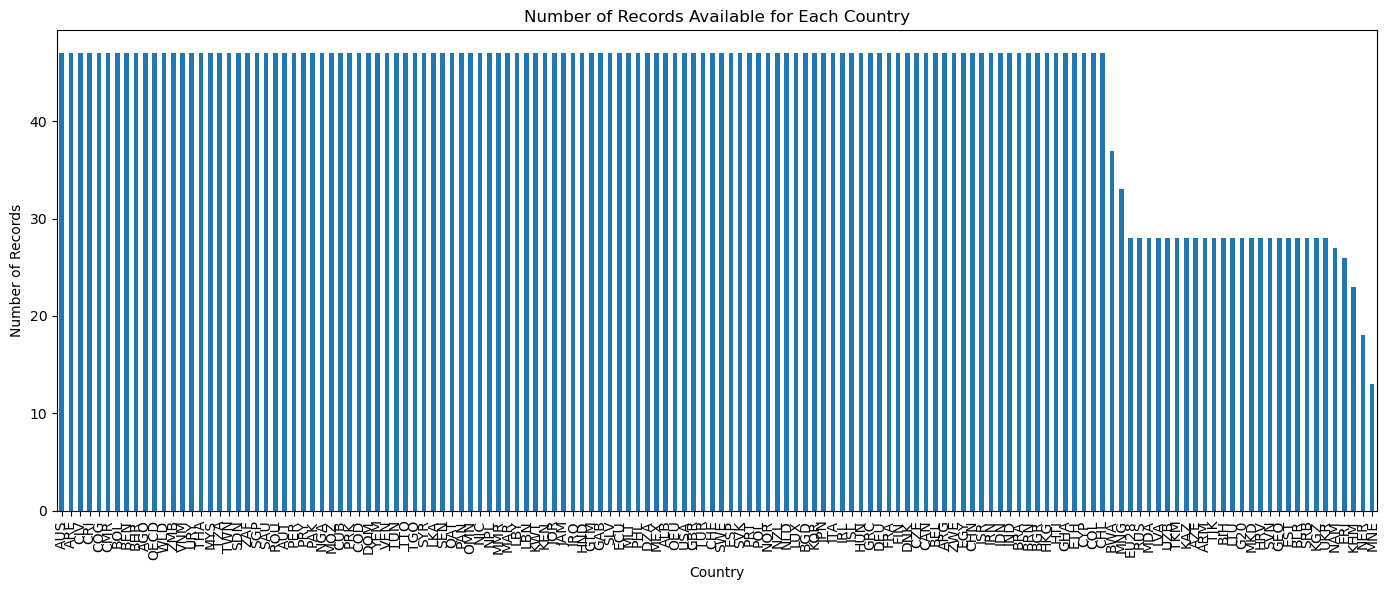

In [25]:
# Count the number of records for each country

country_counts = crude_oil_data["Country"].value_counts()

# Create a bar chart

plt.figure(figsize=(14,6))

country_counts.plot(kind="bar")

plt.title("Number of Records Available for Each Country")
plt.xlabel("Country")
plt.ylabel("Number of Records")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

### Key Observation

The dataset contains production records from multiple countries. Most countries have a similar number of yearly observations, indicating that the dataset provides consistent historical coverage for crude oil production analysis.

## Top 10 Crude Oil Producing Countries

### Objective

This analysis identifies the countries with the highest total crude oil production across all available years. Understanding the leading producers provides valuable insights into global oil production patterns.

In [26]:
# Calculate total oil production by country

top_10_countries = (
    crude_oil_data
    .groupby("Country")["Oil_Production"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_10_countries

Country
WLD     1.524312e+08
G20     5.516837e+07
OECD    3.777444e+07
SAU     1.874380e+07
USA     1.763594e+07
RUS     1.175249e+07
IRN     8.768677e+06
OEU     8.633181e+06
VEN     6.827374e+06
CHN     6.813617e+06
Name: Oil_Production, dtype: float64

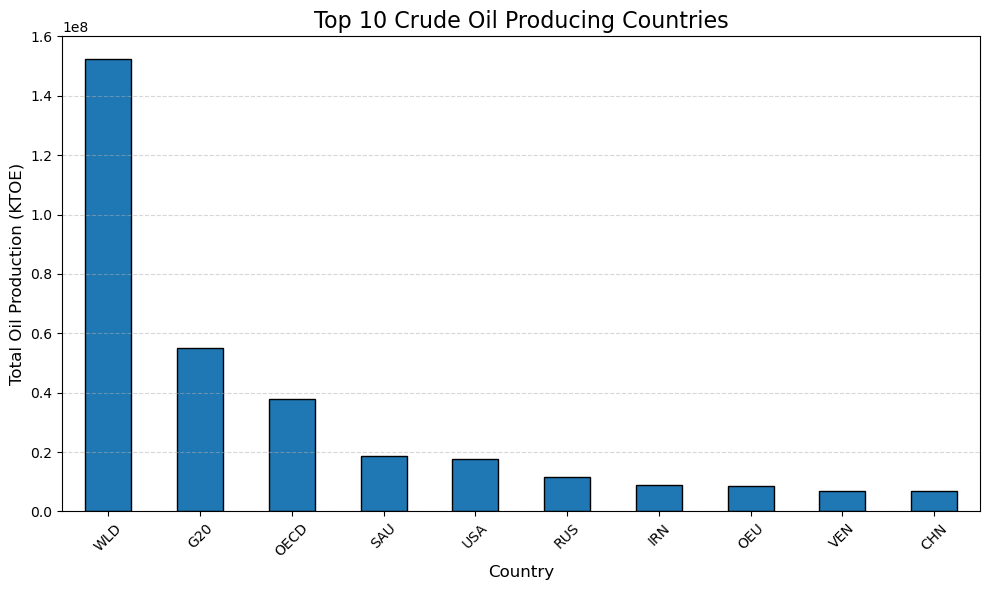

In [27]:
# Plot the Top 10 Crude Oil Producing Countries

plt.figure(figsize=(10,6))

top_10_countries.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Top 10 Crude Oil Producing Countries", fontsize=16)
plt.xlabel("Country", fontsize=12)
plt.ylabel("Total Oil Production (KTOE)", fontsize=12)

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

### Key Observation

The visualization highlights the ten countries with the highest cumulative crude oil production over the study period. A relatively small number of countries account for a substantial share of total production, demonstrating that global crude oil production is concentrated among major oil-producing nations.

## EDA 3: Global Crude Oil Production Trend

### Objective

The objective of this analysis is to examine how global crude oil production has changed over time. By analyzing yearly production trends, we can identify periods of growth, decline, or stability.

In [28]:
# Calculate total global oil production for each year

yearly_production = (
    crude_oil_data
    .groupby("Year")["Oil_Production"]
    .sum()
)

# Display the first five rows

yearly_production.head()

Year
1971    5187637.480
1972    5457552.895
1973    5902349.836
1974    5857630.192
1975    5548266.607
Name: Oil_Production, dtype: float64

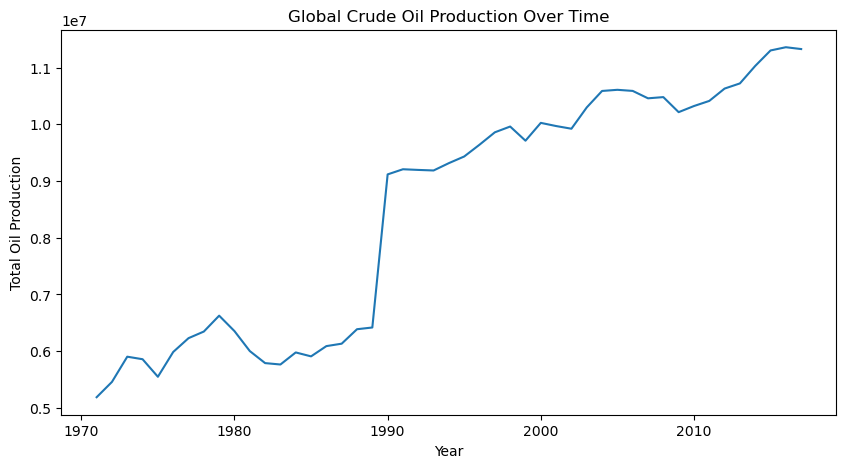

In [29]:
# Plot yearly oil production

plt.figure(figsize=(10,5))

plt.plot(yearly_production.index, yearly_production.values)

plt.title("Global Crude Oil Production Over Time")
plt.xlabel("Year")
plt.ylabel("Total Oil Production")

plt.show()

### Key Observation

The line chart shows how global crude oil production has changed over the years. Overall, crude oil production has generally increased over time, although there are some fluctuations during certain years. This indicates that global oil production has grown significantly over the study period.

## EDA 4: Distribution of Crude Oil Production

### Question

**How are crude oil production values distributed across the dataset?**

### Objective

The objective of this analysis is to understand how crude oil production values are distributed. This helps identify whether most production values are concentrated within a particular range or spread across a wide range of values.

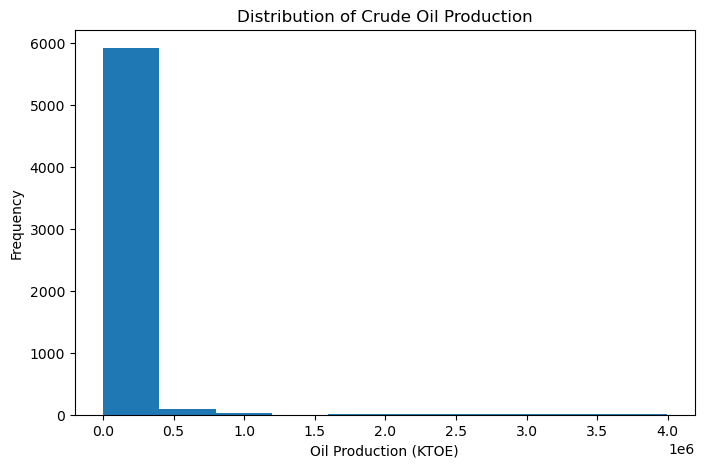

In [30]:
# Plot the distribution of crude oil production values

plt.figure(figsize=(8,5))

plt.hist(crude_oil_data["Oil_Production"])

plt.title("Distribution of Crude Oil Production")
plt.xlabel("Oil Production (KTOE)")
plt.ylabel("Frequency")

plt.show()

### Key Observation

The histogram shows that most crude oil production values are concentrated in the lower production range, while only a small number of observations have very high production values. This indicates that high crude oil production is limited to a few countries or years.

## EDA 5: Detecting Outliers in Crude Oil Production

### Question

**Are there any unusually high or low crude oil production values in the dataset?**

### Objective

The objective of this analysis is to identify any outliers in crude oil production values. Detecting outliers helps us understand whether a few observations differ significantly from the rest of the dataset.

In [31]:
# Display the top 10 years with the highest oil production

top_10_years = yearly_production.sort_values(ascending=False).head(10)

top_10_years

Year
2016    1.135887e+07
2017    1.132655e+07
2015    1.130179e+07
2014    1.102896e+07
2013    1.072079e+07
2012    1.062979e+07
2005    1.060794e+07
2006    1.058866e+07
2004    1.058784e+07
2008    1.047929e+07
Name: Oil_Production, dtype: float64

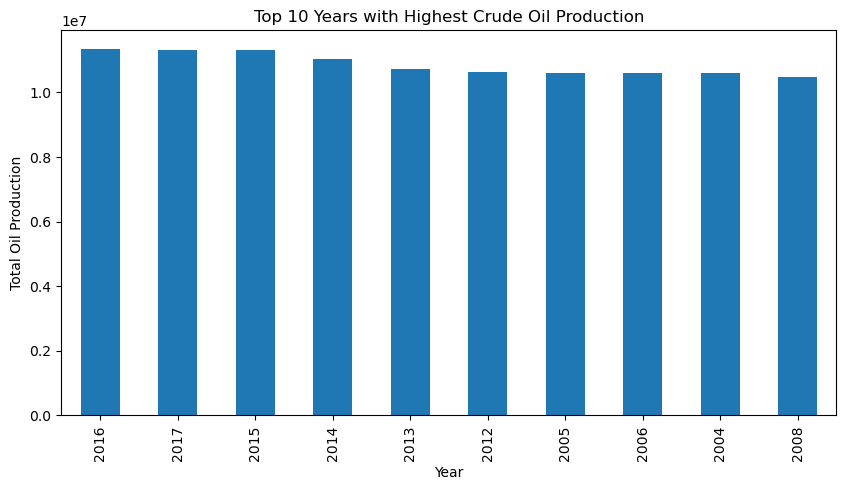

In [32]:
plt.figure(figsize=(10,5))

top_10_years.plot(kind="bar")

plt.title("Top 10 Years with Highest Crude Oil Production")
plt.xlabel("Year")
plt.ylabel("Total Oil Production")

plt.show()

### Key Observation

The chart highlights the ten years with the highest global crude oil production. Most of these years are from the later part of the dataset, indicating that crude oil production generally increased over time.

# Key Insights

- The dataset contains crude oil production data from multiple countries over several decades.

- A small number of countries contribute a significant share of the world's crude oil production.

- Global crude oil production has generally increased over time, although some fluctuations are observed.

- Most crude oil production values are concentrated in the lower range, while only a few countries produce exceptionally high amounts.

- The highest production levels are recorded during the later years of the dataset, indicating long-term growth in global crude oil production.

# Conclusion

This project explored global crude oil production using Python, Pandas, and Matplotlib.

The analysis began with understanding and cleaning the dataset by removing unnecessary columns and handling missing values. Exploratory Data Analysis (EDA) was then performed to identify production trends, leading oil-producing countries, yearly production patterns, and the overall distribution of production values.

Overall, this project demonstrates how data analysis can be used to transform raw data into meaningful insights. It also strengthened practical skills in data cleaning, visualization, and interpreting real-world datasets.